# RAMSES ↔ pyCALIMA Equilibrium Comparison

This notebook loads a RAMSES G8 galaxy simulation (0.1 Z☉, `output_00081`) and compares the **time-evolved dust distribution** from the simulation against the **equilibrium dust distribution** predicted by pyCALIMA.

### Workflow
1. Load the RAMSES output with `yt`, define corrected dust fields
2. Explore the raw simulation data (T-nH phase space, σ, metallicity)
3. Build a 2D (T, nH) equilibrium grid using pyCALIMA's Newton-Krylov solver
4. Interpolate equilibrium predictions onto simulation cells
5. Compare: T-nH phase diagrams, DTM distributions, mass by size/composition

### Key corrections
- **Silicate SioverSil = 0.163**: `dust_bin03` and `dust_bin04` in the RAMSES output store the *Si mass fraction*, not the total silicate mass. Actual silicate density = stored × ρ_gas / 0.163 (Dubois+ 2024 convention).
- **G0 = 1 Habing**: The UV field is not stored in the RAMSES output; G0 = 1 is assumed throughout.
- **σ_turb from `scalar_14`**: The 20th hydro variable is the local turbulent velocity dispersion (km/s).

In [1]:
%matplotlib inline
import sys, os, json
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import yt
from scipy.interpolate import RegularGridInterpolator

# ── pyCALIMA path ──────────────────────────────────────────────────────────────
PYCALIMA_DIR = os.path.expanduser('~/Documents/GitHub/pyCALIMA')
if PYCALIMA_DIR not in sys.path:
    sys.path.insert(0, PYCALIMA_DIR)

from solvers.run_grid import run_grid, save_grid_npz, load_grid_npz

yt.set_log_level('critical')  # suppress yt verbose output
print('yt version:', yt.__version__)

yt version: 4.4.2


In [2]:
# ── Paths and physical constants ───────────────────────────────────────────────
RAMSES_OUTPUT = os.path.expanduser(
    '~/Documents/RAMSES_dev/pyCALIMA_testing/test_outputs'
    '/CorrectSN_0.1Zsun_DTMini1d-3_MR/output_00081'
)
CONFIG_PATH   = os.path.join(PYCALIMA_DIR, 'solvers/configs/ramses_G8_0.1Zsun.json')
GRID_CACHE    = os.path.join(PYCALIMA_DIR, 'results/eq_grid_G8_0.1Zsun.npz')

SioverSil = 0.163    # Si mass fraction inside silicate grain (Dubois+ 2024)
G0_ASSUMED = 1.0     # Habing units — not stored in RAMSES output
ZSUN  = 0.0134       # Solar metallicity, Asplund+ 2009
MH    = 1.6726e-24   # proton mass [g]
MU    = 1.4          # mean molecular weight (neutral ISM default)
KB    = 1.3806e-16   # Boltzmann constant [erg/K]

BOX_HALF_KPC = 4.0   # restrict analysis to a cube of side 2×4 = 8 kpc

# ── Working directory and results folder ──────────────────────────────────────
os.chdir(PYCALIMA_DIR)
os.makedirs('results', exist_ok=True)

print(f'Working directory: {os.getcwd()}')
print(f'Analysis box: {2*BOX_HALF_KPC:.0f} kpc cube centred on domain centre')

Working directory: /Users/currodri/Documents/GitHub/pyCALIMA
Analysis box: 8 kpc cube centred on domain centre


## 1. Load RAMSES output and define derived fields

The simulation has 20 hydro variables (see `hydro_file_descriptor.txt`): density, 3 velocities, pressure, metallicity (gas-phase), 8 element mass fractions (H,O,Fe,Mg,C,N,Si,S), D, 4 dust bins, and `scalar_14` (σ_turb).

> **Note**: `eq_analysis.py` in `models/tools/` uses field names from an *older* RAMSES simulation (`CSmall`, `SilSmall`, etc.). Here we use the field names as written in `hydro_file_descriptor.txt` of this specific output.

In [3]:
def register_pyCALIMA_fields(ds, SioverSil=0.163):
    """Register corrected dust fields for this RAMSES output.

    yt 4.x naming for this RAMSES output (from hydro_file_descriptor.txt):
        ('ramses', 'Density')            — gas mass density  [capitalised]
        ('ramses', 'Metallicity')        — gas-phase metal mass fraction
        ('ramses', 'hydro_dust_bin01')   — small carb dust mass frac
        ('ramses', 'hydro_dust_bin02')   — large carb dust mass frac
        ('ramses', 'hydro_dust_bin03')   — small sil Si-fraction
        ('ramses', 'hydro_dust_bin04')   — large sil Si-fraction
        ('ramses', 'hydro_scalar_14')    — σ_turb [km/s, stored as dimensionless float]
        ('ramses', 'hydro_chem_C/Si/...')— element mass fracs

    ('gas', 'density') and ('gas', 'temperature') are yt-derived from the above.
    """
    _Si = SioverSil

    def _nH(field, data):
        return (data[('gas', 'density')] / (MU * yt.units.mh)).to('1/cm**3')
    ds.add_field(('gas', 'nH'), function=_nH, units='1/cm**3',
                 sampling_type='cell', force_override=True)

    def _sigma(field, data):
        # scalar_14 stores σ_turb in physical km/s as a dimensionless float;
        # attach km/s units directly rather than calling .to() on a dimensionless array
        return data[('ramses', 'hydro_scalar_14')] * yt.units.km / yt.units.s
    ds.add_field(('gas', 'sigma_turb'), function=_sigma, units='km/s',
                 sampling_type='cell', force_override=True)

    def _cs(field, data):
        return (data[('ramses', 'hydro_dust_bin01')] * data[('gas', 'density')]).to('g/cm**3')
    ds.add_field(('gas', 'rho_carb_small'), function=_cs, units='g/cm**3',
                 sampling_type='cell', force_override=True)

    def _cl(field, data):
        return (data[('ramses', 'hydro_dust_bin02')] * data[('gas', 'density')]).to('g/cm**3')
    ds.add_field(('gas', 'rho_carb_large'), function=_cl, units='g/cm**3',
                 sampling_type='cell', force_override=True)

    def _ss(field, data):
        return (data[('ramses', 'hydro_dust_bin03')] * data[('gas', 'density')] / _Si).to('g/cm**3')
    ds.add_field(('gas', 'rho_sil_small'), function=_ss, units='g/cm**3',
                 sampling_type='cell', force_override=True)

    def _sl(field, data):
        return (data[('ramses', 'hydro_dust_bin04')] * data[('gas', 'density')] / _Si).to('g/cm**3')
    ds.add_field(('gas', 'rho_sil_large'), function=_sl, units='g/cm**3',
                 sampling_type='cell', force_override=True)


ds = yt.load(RAMSES_OUTPUT)
register_pyCALIMA_fields(ds)

print(f'Simulation time: {ds.current_time.to("Myr"):.1f}')
print(f'Box size:        {ds.domain_width[0].to("kpc"):.0f}')
print(f'Max AMR level:   {ds.max_level}')
print(f'Available ramses fields: {[f[1] for f in ds.field_list if f[0]=="ramses"]}')

Simulation time: 399.4 Myr
Box size:        150 kpc
Max AMR level:   7
Available ramses fields: ['Density', 'Metallicity', 'Pressure', 'hydro_chem_C', 'hydro_chem_D', 'hydro_chem_Fe', 'hydro_chem_H', 'hydro_chem_Mg', 'hydro_chem_N', 'hydro_chem_O', 'hydro_chem_S', 'hydro_chem_Si', 'hydro_dust_bin01', 'hydro_dust_bin02', 'hydro_dust_bin03', 'hydro_dust_bin04', 'hydro_scalar_14', 'x-velocity', 'y-velocity', 'z-velocity']


## 2. Sanity-check projections

Three yt projection plots to verify the dataset loaded correctly: column gas density, mass-weighted temperature, and mass-weighted gas-phase metallicity, all projected along the z-axis.

Saved results/proj_density.png



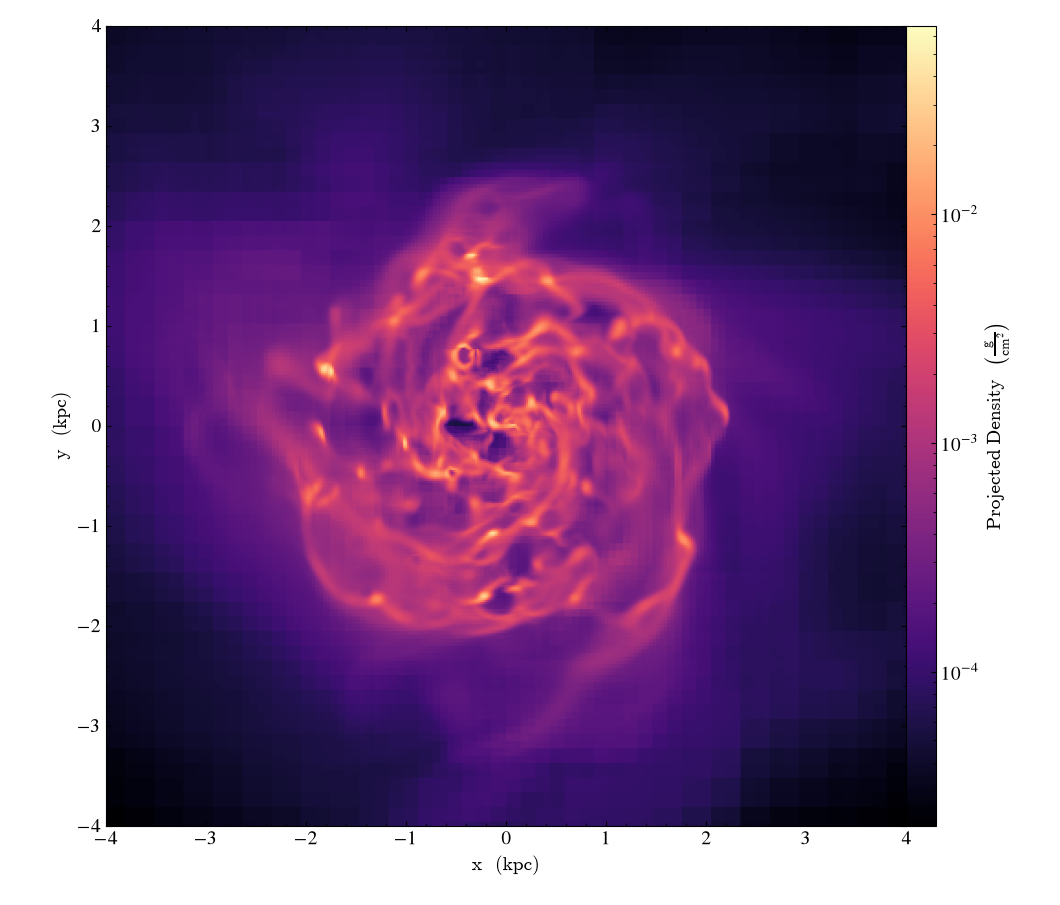

Saved results/proj_temperature.png



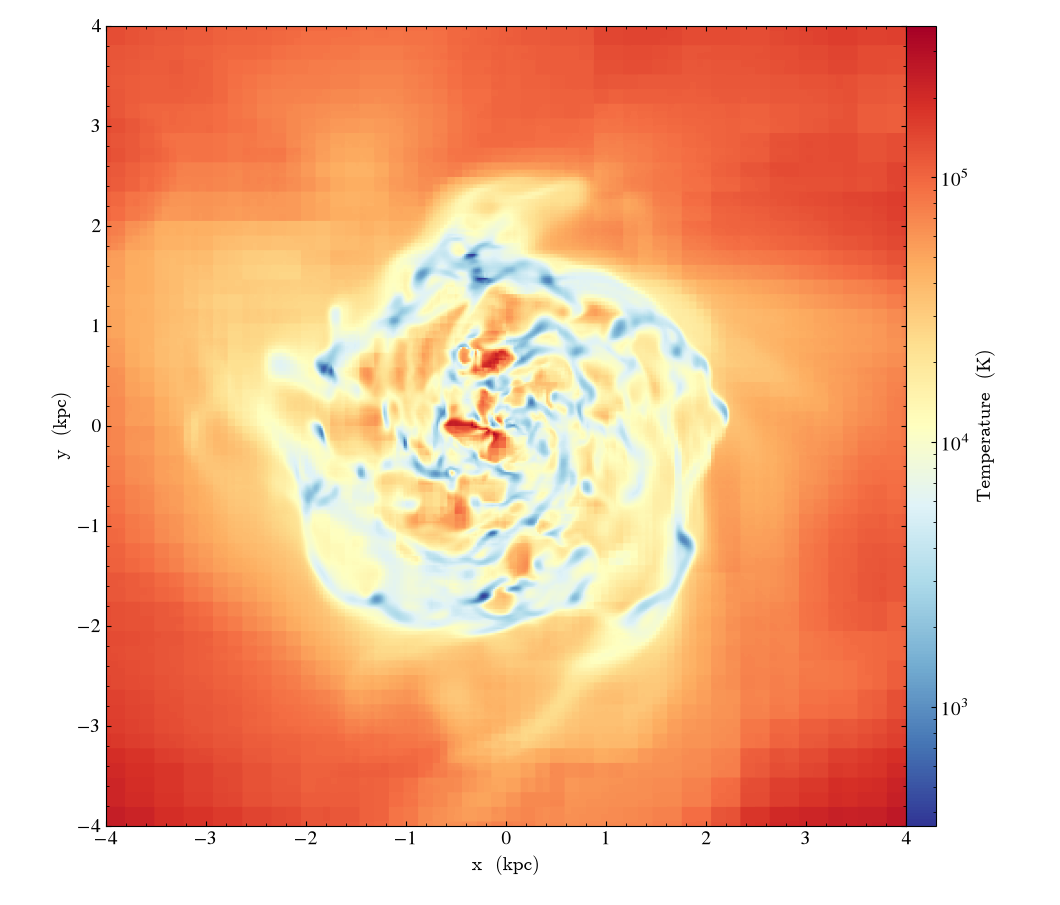

Saved results/proj_metallicity.png



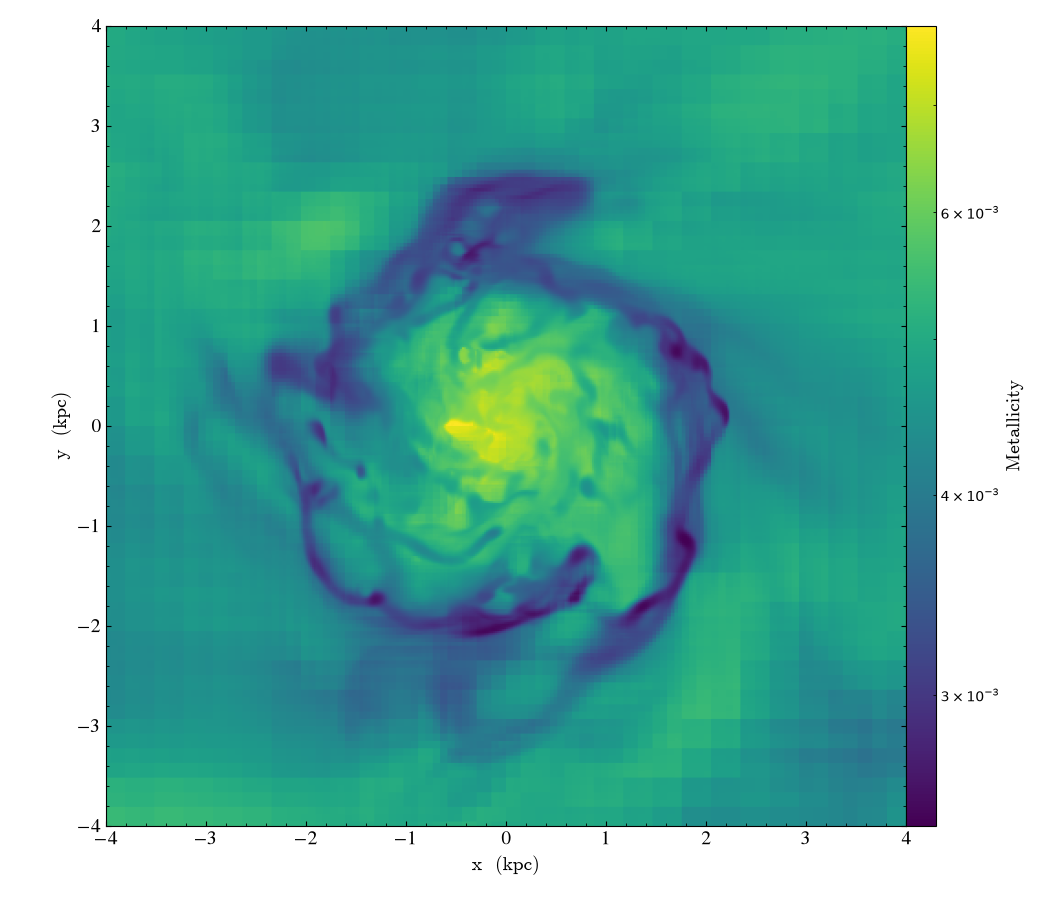

In [4]:
os.makedirs('results', exist_ok=True)

PROJ_AXIS  = 'z'
PROJ_WIDTH = (2 * BOX_HALF_KPC, 'kpc')   # 8 kpc window — same as analysis box

PROJ_FIELDS = [
    # (field,                      weight_field,          output_name,  cmap)
    (('gas', 'density'),           None,                  'density',    'magma'),
    (('gas', 'temperature'),       ('gas', 'density'),    'temperature','RdYlBu_r'),
    (('ramses', 'Metallicity'),    ('gas', 'density'),    'metallicity','viridis'),
]

for field, weight, name, cmap in PROJ_FIELDS:
    p = yt.ProjectionPlot(ds, PROJ_AXIS, field, weight_field=weight,
                          center=ds.domain_center, width=PROJ_WIDTH)
    p.set_cmap(field, cmap)
    p.set_font({'size': 14})
    fname = f'results/proj_{name}.png'
    p.save(fname)
    print(f'Saved {fname}')
    p.show()

## 3. Extract cell data as numpy arrays

In [5]:
# ── Restrict to 8 kpc cube centred on the domain centre ──────────────────────
half = ds.quan(BOX_HALF_KPC, 'kpc')
ad   = ds.box(ds.domain_center - half, ds.domain_center + half)
print(f'Cells in 8 kpc box: {ad[("gas","density")].shape[0]:,}')

# ── Gas state ─────────────────────────────────────────────────────────────────
rho   = ad[('gas', 'density')].to('g/cm**3').value          # g/cm³
T_gas = ad[('gas', 'temperature')].to('K').value             # K
nH    = ad[('gas', 'nH')].to('1/cm**3').value               # cm⁻³
sigma = ad[('gas', 'sigma_turb')].to('km/s').value           # km/s
vol   = ad[('index', 'cell_volume')].to('cm**3').value       # cm³

# ── Metallicity (point 3): 'Metallicity' = total metal mass fraction (gas+dust)
#    No approximation needed — use the RAMSES field directly.
Z_metal = ad[('ramses', 'Metallicity')].value                # gas+dust metals/ρ
rho_metal = Z_metal * rho                                    # total metal mass density [g/cm³]

# ── Individual element mass fractions (point 4): chem_X = gas+dust combined ──
fH  = ad[('ramses', 'hydro_chem_H')].value
fC  = ad[('ramses', 'hydro_chem_C')].value
fN  = ad[('ramses', 'hydro_chem_N')].value
fO  = ad[('ramses', 'hydro_chem_O')].value
fMg = ad[('ramses', 'hydro_chem_Mg')].value
fSi = ad[('ramses', 'hydro_chem_Si')].value
fS  = ad[('ramses', 'hydro_chem_S')].value
fFe = ad[('ramses', 'hydro_chem_Fe')].value

# ── Corrected absolute dust mass densities [g/cm³] ───────────────────────────
rho_cs = ad[('gas', 'rho_carb_small')].to('g/cm**3').value
rho_cl = ad[('gas', 'rho_carb_large')].to('g/cm**3').value
rho_ss = ad[('gas', 'rho_sil_small')].to('g/cm**3').value
rho_sl = ad[('gas', 'rho_sil_large')].to('g/cm**3').value
rho_dust = rho_cs + rho_cl + rho_ss + rho_sl

# ── Cell mass for mass-weighting ──────────────────────────────────────────────
cell_mass = rho * vol

# ── DTM: dust mass / total metal mass (both gas+dust metals in denominator) ──
with np.errstate(invalid='ignore', divide='ignore'):
    DTM_sim = np.where(rho_metal > 0, rho_dust / rho_metal, 0.0)

print(f'Total gas mass:  {cell_mass.sum():.3e} g')
print(f'Total dust mass: {(rho_dust * vol).sum():.3e} g')
print(f'Global DTM:      {(rho_dust * vol).sum() / (rho_metal * vol).sum():.4f}')
print(f'Mean Z_metal:    {np.average(Z_metal, weights=cell_mass):.4e}  '
      f'({np.average(Z_metal, weights=cell_mass)/ZSUN:.3f} Zsun)')

Cells in 8 kpc box: 1,124,140


Total gas mass:  2.380e+41 g
Total dust mass: 2.277e+38 g
Global DTM:      0.2172
Mean Z_metal:    4.4040e-03  (0.329 Zsun)


## 4. Sanity-check distributions

Mass-weighted histograms of the three key ISM state variables, plus the T-nH phase diagram.  These four panels confirm the simulation spans the expected temperature, density, and metallicity ranges.

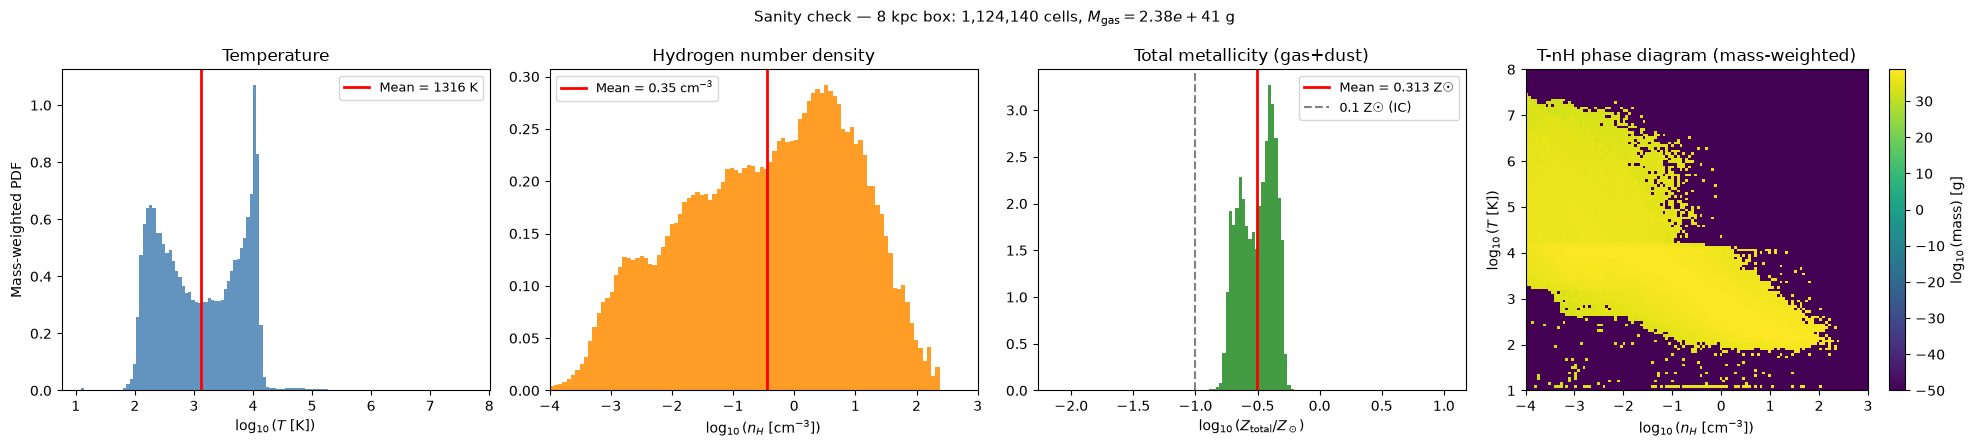

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

mask = (T_gas > 0) & (nH > 0) & (Z_metal > 0)
mw   = cell_mass[mask]

# ── Temperature histogram ─────────────────────────────────────────────────────
ax = axes[0]
ax.hist(np.log10(T_gas[mask]), bins=120, weights=mw, density=True,
        color='steelblue', alpha=0.85)
T_mw = np.average(np.log10(T_gas[mask]), weights=mw)
ax.axvline(T_mw, color='red', lw=2, label=f'Mean = {10**T_mw:.0f} K')
ax.set_xlabel(r'$\log_{10}(T\ [\mathrm{K}])$')
ax.set_ylabel('Mass-weighted PDF')
ax.set_title('Temperature')
ax.legend(fontsize=9)

# ── nH histogram ─────────────────────────────────────────────────────────────
ax = axes[1]
ax.hist(np.log10(nH[mask]), bins=120, weights=mw, density=True,
        color='darkorange', alpha=0.85)
nH_mw = np.average(np.log10(nH[mask]), weights=mw)
ax.axvline(nH_mw, color='red', lw=2,
           label=fr'Mean = {10**nH_mw:.2g} cm$^{{-3}}$')
ax.set_xlabel(r'$\log_{10}(n_H\ [\mathrm{cm}^{-3}])$')
ax.set_xlim(-4, 3)
ax.set_title('Hydrogen number density')
ax.legend(fontsize=9)

# ── Metallicity histogram — use total metal fraction directly ─────────────────
ax = axes[2]
ax.hist(np.log10(Z_metal[mask] / ZSUN), bins=120, weights=mw, density=True,
        color='forestgreen', alpha=0.85)
Z_mw = np.average(np.log10(Z_metal[mask] / ZSUN), weights=mw)
ax.axvline(Z_mw, color='red', lw=2, label=f'Mean = {10**Z_mw:.3f} Z☉')
ax.axvline(np.log10(0.1), color='gray', lw=1.5, ls='--', label='0.1 Z☉ (IC)')
ax.set_xlabel(r'$\log_{10}(Z_\mathrm{total}/Z_\odot)$')
ax.set_title('Total metallicity (gas+dust)')
ax.legend(fontsize=9)

# ── T-nH phase diagram ───────────────────────────────────────────────────────
ax = axes[3]
h, xe, ye = np.histogram2d(
    np.log10(nH[mask]), np.log10(T_gas[mask]),
    bins=120, range=[(-4, 3), (1, 8)], weights=mw
)
im = ax.pcolormesh(xe, ye, np.log10(h.T + 1e-50), cmap='viridis')
plt.colorbar(im, ax=ax, label=r'$\log_{10}$(mass) [g]')
ax.set_xlabel(r'$\log_{10}(n_H\ [\mathrm{cm}^{-3}])$')
ax.set_ylabel(r'$\log_{10}(T\ [\mathrm{K}])$')
ax.set_title('T-nH phase diagram (mass-weighted)')

plt.suptitle(
    f'Sanity check — 8 kpc box: {len(T_gas):,} cells, '
    fr'$M_\mathrm{{gas}} = {cell_mass.sum():.2e}$ g',
    fontsize=11
)
plt.tight_layout()
plt.savefig('results/sanity_check_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Detailed exploration: phase space, σ_turb, and metallicity budget

Before building the equilibrium grid we need to know the T-nH range covered by the simulation and the typical turbulent velocity dispersion (which sets the turbulence parameter in the config).

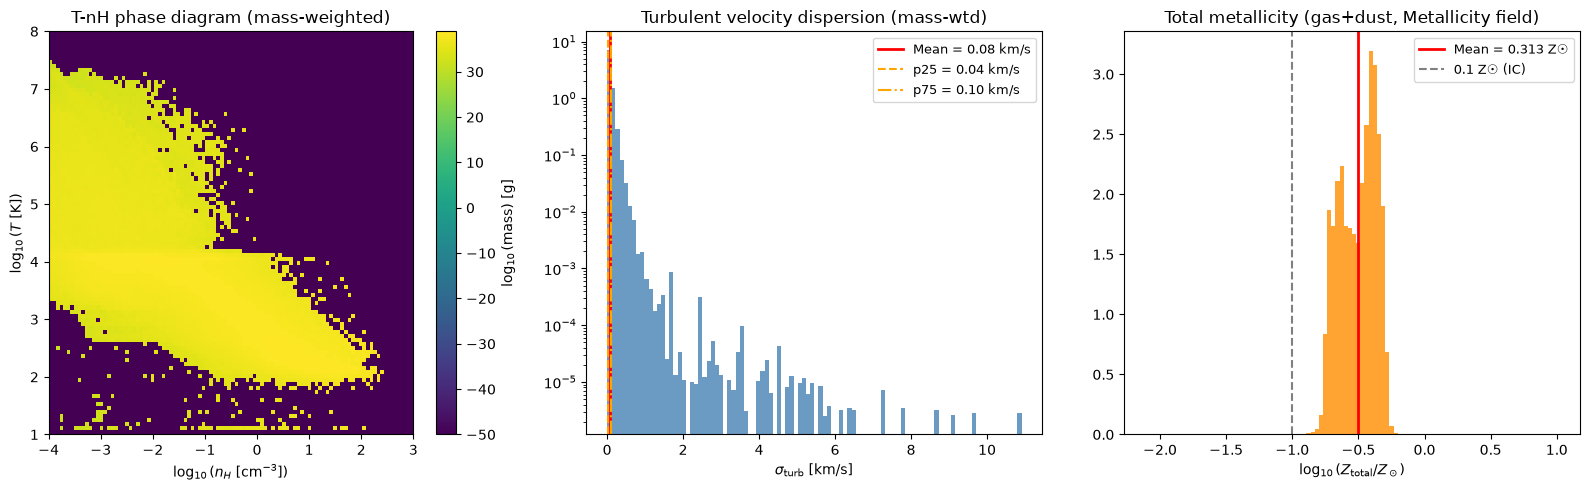

T  5th–95th: 4.7e+02 – 1.2e+06 K
nH 5th–95th: 1.80e-04 – 1.09e+00 cm⁻³
sigma mass-weighted mean: 0.08 km/s


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

mask = (T_gas > 0) & (nH > 0)

# ── Panel 1: mass-weighted T-nH phase diagram ─────────────────────────────────
ax = axes[0]
h, xe, ye = np.histogram2d(
    np.log10(nH[mask]), np.log10(T_gas[mask]),
    bins=100, range=[(-4, 3), (1, 8)],
    weights=cell_mass[mask]
)
im0 = ax.pcolormesh(xe, ye, np.log10(h.T + 1e-50), cmap='viridis', vmin=None)
plt.colorbar(im0, ax=ax, label=r'$\log_{10}$(mass) [g]')
ax.set_xlabel(r'$\log_{10}(n_H\ [\mathrm{cm}^{-3}])$')
ax.set_ylabel(r'$\log_{10}(T\ [\mathrm{K}])$')
ax.set_title('T-nH phase diagram (mass-weighted)')

# ── Panel 2: mass-weighted sigma distribution ─────────────────────────────────
ax = axes[1]
smask = (sigma > 0) & mask
ax.hist(sigma[smask], bins=100, weights=cell_mass[smask], density=True, log=True,
        color='steelblue', alpha=0.8)
sigma_mw = np.average(sigma[smask], weights=cell_mass[smask])
sigma_p25, sigma_p75 = np.percentile(sigma[smask], [25, 75])
ax.axvline(sigma_mw, color='red',    lw=2, label=f'Mean = {sigma_mw:.2f} km/s')
ax.axvline(sigma_p25, color='orange', lw=1.5, ls='--', label=f'p25 = {sigma_p25:.2f} km/s')
ax.axvline(sigma_p75, color='orange', lw=1.5, ls='-.', label=f'p75 = {sigma_p75:.2f} km/s')
ax.set_xlabel(r'$\sigma_\mathrm{turb}$ [km/s]')
ax.set_title('Turbulent velocity dispersion (mass-wtd)')
ax.legend(fontsize=9)

# ── Panel 3: total metallicity distribution (from Metallicity field directly) ─
ax = axes[2]
Zmask = mask & (Z_metal > 0)
ax.hist(np.log10(Z_metal[Zmask] / ZSUN), bins=100,
        weights=cell_mass[Zmask], density=True,
        color='darkorange', alpha=0.8)
Z_mw_log = np.average(np.log10(Z_metal[Zmask] / ZSUN), weights=cell_mass[Zmask])
ax.axvline(Z_mw_log, color='red', lw=2, label=f'Mean = {10**Z_mw_log:.3f} Z☉')
ax.axvline(np.log10(0.1), color='gray', lw=1.5, ls='--', label='0.1 Z☉ (IC)')
ax.set_xlabel(r'$\log_{10}(Z_\mathrm{total}/Z_\odot)$')
ax.set_title('Total metallicity (gas+dust, Metallicity field)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('results/exploration_phase_sigma_Z.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Grid design stats ─────────────────────────────────────────────────────────
T_p05, T_p95   = np.percentile(T_gas[mask], [5, 95])
nH_p05, nH_p95 = np.percentile(nH[mask], [5, 95])

print(f'T  5th–95th: {T_p05:.1e} – {T_p95:.1e} K')
print(f'nH 5th–95th: {nH_p05:.2e} – {nH_p95:.2e} cm⁻³')
print(f'sigma mass-weighted mean: {sigma_mw:.2f} km/s')

## 6. Simulation dust distribution on T-nH plane

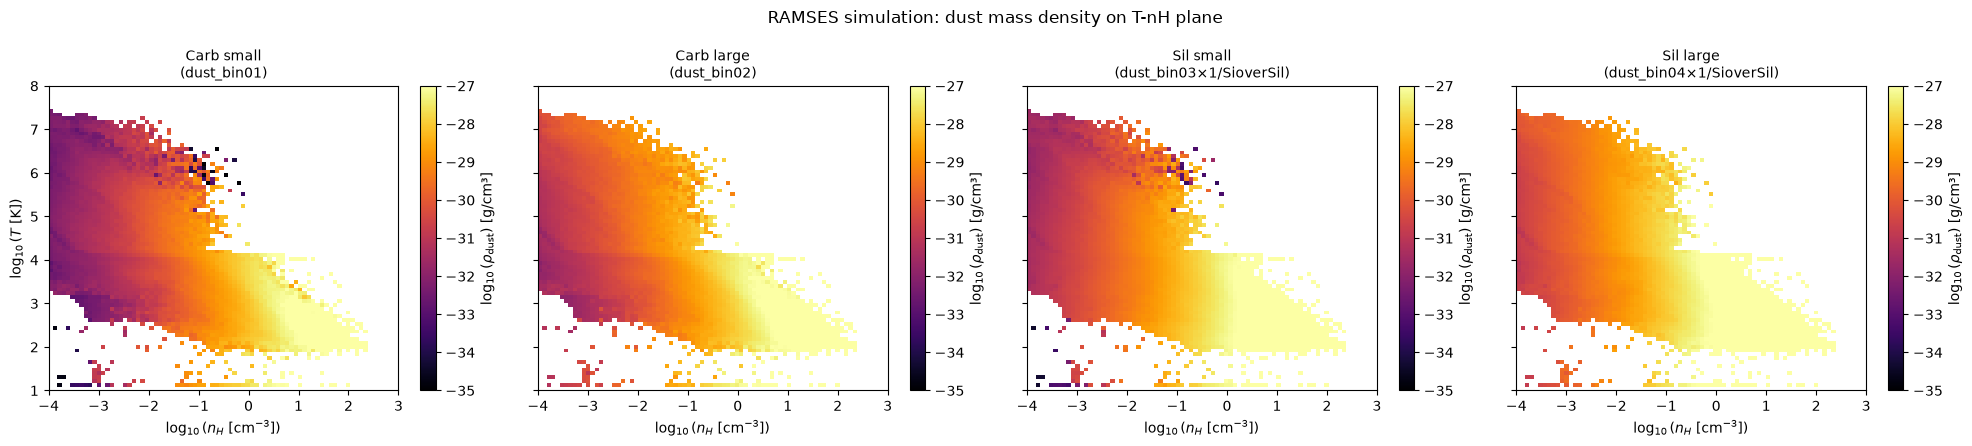

In [8]:
BIN_LABELS  = ['Carb small\n(dust_bin01)', 'Carb large\n(dust_bin02)',
               'Sil small\n(dust_bin03×1/SioverSil)', 'Sil large\n(dust_bin04×1/SioverSil)']
SIM_BINS    = [rho_cs, rho_cl, rho_ss, rho_sl]

NBINS_2D = 80
NH_RANGE = (-4, 3)   # nH: 1e-4 to 1e3 cm-3
T_RANGE  = (1, 8)


def phase_rho_dust(T, nH, rho_bins, labels, vol_weights, figsize=(20, 4.5),
                   vmin=-35, vmax=-27, title=''):
    """2D histogram of T-nH coloured by volume-weighted mean dust mass density."""
    fig, axes = plt.subplots(1, len(rho_bins), figsize=figsize, sharey=True)
    log_nH = np.log10(np.clip(nH, 1e-5, 1e4))
    log_T  = np.log10(np.clip(T,  1e0,  1e9))

    for ax, rho_bin, label in zip(axes, rho_bins, labels):
        h_w, xe, ye = np.histogram2d(log_nH, log_T, bins=NBINS_2D,
                                      range=[NH_RANGE, T_RANGE],
                                      weights=rho_bin * vol_weights)
        h_v, _,  _  = np.histogram2d(log_nH, log_T, bins=NBINS_2D,
                                      range=[NH_RANGE, T_RANGE],
                                      weights=vol_weights)
        with np.errstate(invalid='ignore', divide='ignore'):
            mean_rho = np.where(h_v > 0, h_w / h_v, np.nan)
        im = ax.pcolormesh(xe, ye, np.log10(np.abs(mean_rho.T) + 1e-50),
                           cmap='inferno', vmin=vmin, vmax=vmax)
        ax.set_xlabel(r'$\log_{10}(n_H\ [\mathrm{cm}^{-3}])$')
        ax.set_title(label, fontsize=10)
        plt.colorbar(im, ax=ax, label=r'$\log_{10}(\rho_\mathrm{dust})$ [g/cm³]')

    axes[0].set_ylabel(r'$\log_{10}(T\ [\mathrm{K}])$')
    if title:
        fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    return fig


fig_sim = phase_rho_dust(
    T_gas, nH, SIM_BINS, BIN_LABELS, vol,
    title='RAMSES simulation: dust mass density on T-nH plane'
)
plt.savefig('results/sim_dust_Tnplane.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Build pyCALIMA equilibrium grid

We use `run_grid()` from `solvers/run_grid.py` to compute the Newton-Krylov equilibrium over a 2D (T, nH) grid, then save to `.npz` for reuse.

The config `ramses_G8_0.1Zsun.json` is updated with the mass-weighted median σ from the simulation before running.

In [9]:
# ── Compute mass-weighted mean element abundances from chem_ fields ───────────
# chem_X = gas+dust total element mass fraction → use directly as total budget
mwt = cell_mass  # mass weights (all cells, no masking needed for means)
fH_mw  = np.average(fH,  weights=mwt)
fC_mw  = np.average(fC,  weights=mwt)
fN_mw  = np.average(fN,  weights=mwt)
fO_mw  = np.average(fO,  weights=mwt)
fMg_mw = np.average(fMg, weights=mwt)
fSi_mw = np.average(fSi, weights=mwt)
fS_mw  = np.average(fS,  weights=mwt)
fFe_mw = np.average(fFe, weights=mwt)
# He is not tracked explicitly; infer from unity: He = 1 - H - all_metals
Z_metal_mw = np.average(Z_metal, weights=mwt)
fHe_mw = max(0.0, 1.0 - fH_mw - Z_metal_mw)

print('Mass-weighted element abundances from simulation:')
for el, val in [('H', fH_mw), ('He', fHe_mw), ('C', fC_mw), ('N', fN_mw),
                ('O', fO_mw), ('Mg', fMg_mw), ('Si', fSi_mw), ('S', fS_mw),
                ('Fe', fFe_mw)]:
    print(f'  {el:2s}: {val:.4e}')
print(f'  sum = {fH_mw+fHe_mw+fC_mw+fN_mw+fO_mw+fMg_mw+fSi_mw+fS_mw+fFe_mw:.6f}')

# ── Update config with sim-derived abundances and median sigma ────────────────
with open(CONFIG_PATH) as f:
    cfg = json.load(f)

cfg['elemental_abundances'] = {
    'H':  {'mass_fraction': float(fH_mw)},
    'He': {'mass_fraction': float(fHe_mw)},
    'C':  {'mass_fraction': float(fC_mw)},
    'N':  {'mass_fraction': float(fN_mw)},
    'O':  {'mass_fraction': float(fO_mw)},
    'Mg': {'mass_fraction': float(fMg_mw)},
    'Si': {'mass_fraction': float(fSi_mw)},
    'S':  {'mass_fraction': float(fS_mw)},
    'Fe': {'mass_fraction': float(fFe_mw)},
}
cfg['turbulence']['local_sigma_km_s'] = float(sigma_mw)
cfg['turbulence']['local_dx_pc']      = 18.0

os.makedirs('results', exist_ok=True)
updated_cfg_path = 'results/ramses_G8_0.1Zsun_rungrid.json'
with open(updated_cfg_path, 'w') as f:
    json.dump(cfg, f, indent=4)

print(f'\nConfig written to: {updated_cfg_path}')
print(f'  sigma = {sigma_mw:.2f} km/s,  dx = 18.0 pc')

# ── Grid bounds (nH: 1e-4 to 1e3 cm-3) ───────────────────────────────────────
T_grid  = np.logspace(
    max(1.0, np.floor(np.log10(T_p05))),
    min(8.0, np.ceil(np.log10(T_p95))),
    30
)
nH_grid = np.logspace(
    max(-4.0, np.floor(np.log10(nH_p05))),
    min(3.0,  np.ceil(np.log10(nH_p95))),
    30
)
print(f'\nGrid T  range: {T_grid[0]:.1e} – {T_grid[-1]:.1e} K  ({len(T_grid)} pts)')
print(f'Grid nH range: {nH_grid[0]:.1e} – {nH_grid[-1]:.1e} cm⁻³ ({len(nH_grid)} pts)')
print(f'Total grid cells: {len(T_grid) * len(nH_grid)}')

Mass-weighted element abundances from simulation:
  H : 7.5391e-01
  He: 2.4169e-01
  C : 7.8024e-04
  N : 2.4238e-04
  O : 2.0335e-03
  Mg: 2.2419e-04
  Si: 2.2274e-04
  S : 1.0595e-04
  Fe: 3.8876e-04
  sum = 0.999594

Config written to: results/ramses_G8_0.1Zsun_rungrid.json
  sigma = 0.08 km/s,  dx = 18.0 pc

Grid T  range: 1.0e+02 – 1.0e+07 K  (30 pts)
Grid nH range: 1.0e-04 – 1.0e+01 cm⁻³ (30 pts)
Total grid cells: 900


In [ ]:
# ── Run or load the equilibrium grid ─────────────────────────────────────────
# Set FORCE_RERUN=True to regenerate the grid even if a cache file exists.
# Required after physics fixes (coagulation kernel, silicate composition, etc.).
FORCE_RERUN = True   # ← set False after first successful run to use the cache

if os.path.exists(GRID_CACHE) and not FORCE_RERUN:
    print('Loading cached equilibrium grid…')
    grid = load_grid_npz(GRID_CACHE)
    print(f'  Loaded: shape {grid["rho_dust"].shape}')
    print(f'  Convergence: {grid["converged"].mean()*100:.1f}%')
else:
    if FORCE_RERUN and os.path.exists(GRID_CACHE):
        os.remove(GRID_CACHE)
        print('Stale cache removed — rerunning with updated physics.')
    print('Running Newton-Krylov equilibrium grid (this may take several minutes)…')
    grid = run_grid(
        updated_cfg_path,
        x_param='T',  x_values=T_grid.tolist(),
        y_param='nH', y_values=nH_grid.tolist(),
        solver_type='newton_krylov',
        n_jobs=8,           # adjust to number of available cores
        verbose=False,
    )
    save_grid_npz(grid, GRID_CACHE)
    print(f'Grid saved to {GRID_CACHE}')
    print(f'Convergence: {grid["converged"].mean()*100:.1f}%')
    print(f'Elapsed:     {grid["elapsed_s"].sum()/60:.1f} min (total solver time)')

## 8. Inspect equilibrium grid convergence and structure

DTM grid shape: (30, 30, 4)
Reference metallicity used: Z_metal_mw = 4.4040e-03 (0.329 Zsun)
Grid convergence per T bin:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


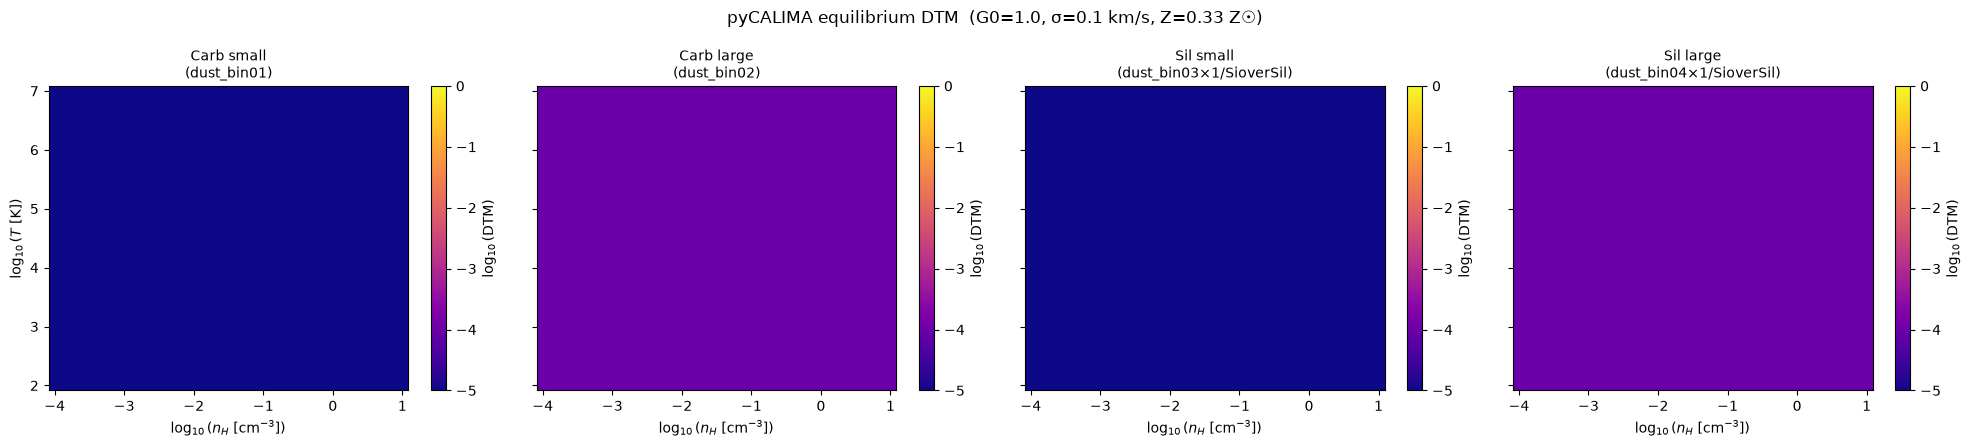

In [11]:
# ── Compute equilibrium DTM for each bin ─────────────────────────────────────
# rho_dust shape: (nT, nNH, ndust=4)
# Use the mass-weighted mean total metallicity from the simulation data
rho_gas_grid   = nH_grid[None, :] * MH * MU          # (1, nNH)  [g/cm³]
rho_metal_grid = Z_metal_mw * rho_gas_grid            # (1, nNH)  — sim-derived Z
DTM_grid = grid['rho_dust'] / rho_metal_grid[:, :, None]  # (nT, nNH, 4)

print('DTM grid shape:', DTM_grid.shape)
print(f'Reference metallicity used: Z_metal_mw = {Z_metal_mw:.4e} ({Z_metal_mw/ZSUN:.3f} Zsun)')
print('Grid convergence per T bin:')
print(grid['converged'].mean(axis=1))

# ── Plot equilibrium DTM on T-nH plane ───────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5), sharey=True)
log_T_g  = np.log10(T_grid)
log_nH_g = np.log10(nH_grid)

for k, (ax, label) in enumerate(zip(axes, BIN_LABELS)):
    vals = np.log10(np.clip(DTM_grid[:, :, k], 1e-6, 1.0))
    im = ax.pcolormesh(log_nH_g, log_T_g, vals,
                       cmap='plasma', vmin=-5, vmax=0)
    nc = ~grid['converged'].astype(bool)
    if nc.any():
        nH_nc = log_nH_g[np.where(nc)[1]]
        T_nc  = log_T_g[np.where(nc)[0]]
        ax.scatter(nH_nc, T_nc, s=5, c='white', marker='x', label='Not converged')
    ax.set_xlabel(r'$\log_{10}(n_H\ [\mathrm{cm}^{-3}])$')
    ax.set_title(label, fontsize=10)
    plt.colorbar(im, ax=ax, label=r'$\log_{10}$(DTM)')

axes[0].set_ylabel(r'$\log_{10}(T\ [\mathrm{K}])$')
fig.suptitle(
    f'pyCALIMA equilibrium DTM  (G0={G0_ASSUMED}, σ={sigma_mw:.1f} km/s, '
    f'Z={Z_metal_mw/ZSUN:.2f} Z☉)',
    fontsize=12
)
plt.tight_layout()
plt.savefig('results/eq_grid_DTM.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Interpolate equilibrium onto simulation cells

In [12]:
# ── Build RegularGridInterpolator for each bin's DTM ─────────────────────────
log_T_ax  = np.log10(T_grid)
log_nH_ax = np.log10(nH_grid)

interps = [
    RegularGridInterpolator(
        (log_T_ax, log_nH_ax), DTM_grid[:, :, k],
        method='linear', bounds_error=False, fill_value=np.nan
    )
    for k in range(4)
]

# ── Map equilibrium DTM to each simulation cell ───────────────────────────────
pts = np.column_stack([
    np.log10(np.clip(T_gas, T_grid[0], T_grid[-1])),
    np.log10(np.clip(nH,    nH_grid[0], nH_grid[-1]))
])

DTM_eq = np.column_stack([interp(pts) for interp in interps])  # (ncells, 4)
DTM_eq = np.clip(DTM_eq, 0.0, None)   # DTM must be non-negative

# Predicted equilibrium dust mass densities (scale by cell's actual metal content)
rho_eq = DTM_eq * rho_metal[:, None]   # (ncells, 4)  [g/cm³]
rho_cs_eq, rho_cl_eq, rho_ss_eq, rho_sl_eq = (
    rho_eq[:, 0], rho_eq[:, 1], rho_eq[:, 2], rho_eq[:, 3]
)
rho_dust_eq = rho_eq.sum(axis=1)

# Fraction of cells that fell outside the grid bounds
out_of_bounds = np.isnan(DTM_eq).any(axis=1)
mass_oob = cell_mass[out_of_bounds].sum() / cell_mass.sum() * 100
print(f'Cells outside grid bounds: {out_of_bounds.sum():,} ({mass_oob:.2f}% of total mass)')

# DTM from equilibrium
with np.errstate(invalid='ignore', divide='ignore'):
    DTM_eq_total = np.where(rho_metal > 0, rho_dust_eq / rho_metal, 0.0)

print(f'Global DTM (simulation):  {(rho_dust    * vol).sum() / (rho_metal * vol).sum():.4f}')
print(f'Global DTM (equilibrium): {(rho_dust_eq * vol[~out_of_bounds]).sum() / (rho_metal[~out_of_bounds] * vol[~out_of_bounds]).sum():.4f}')

Cells outside grid bounds: 0 (0.00% of total mass)
Global DTM (simulation):  0.2172
Global DTM (equilibrium): 0.0002


## 10. Comparison: T-nH phase diagrams

Side-by-side comparison of the simulation dust density vs. the equilibrium prediction on the T-nH plane.

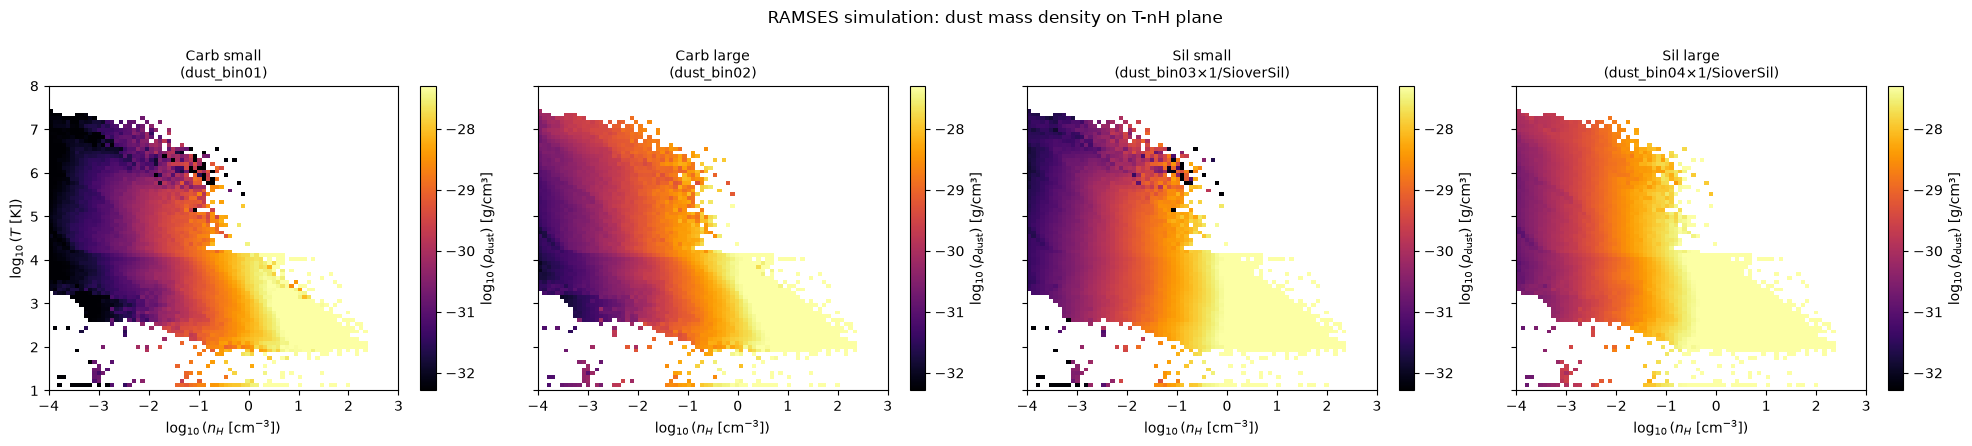

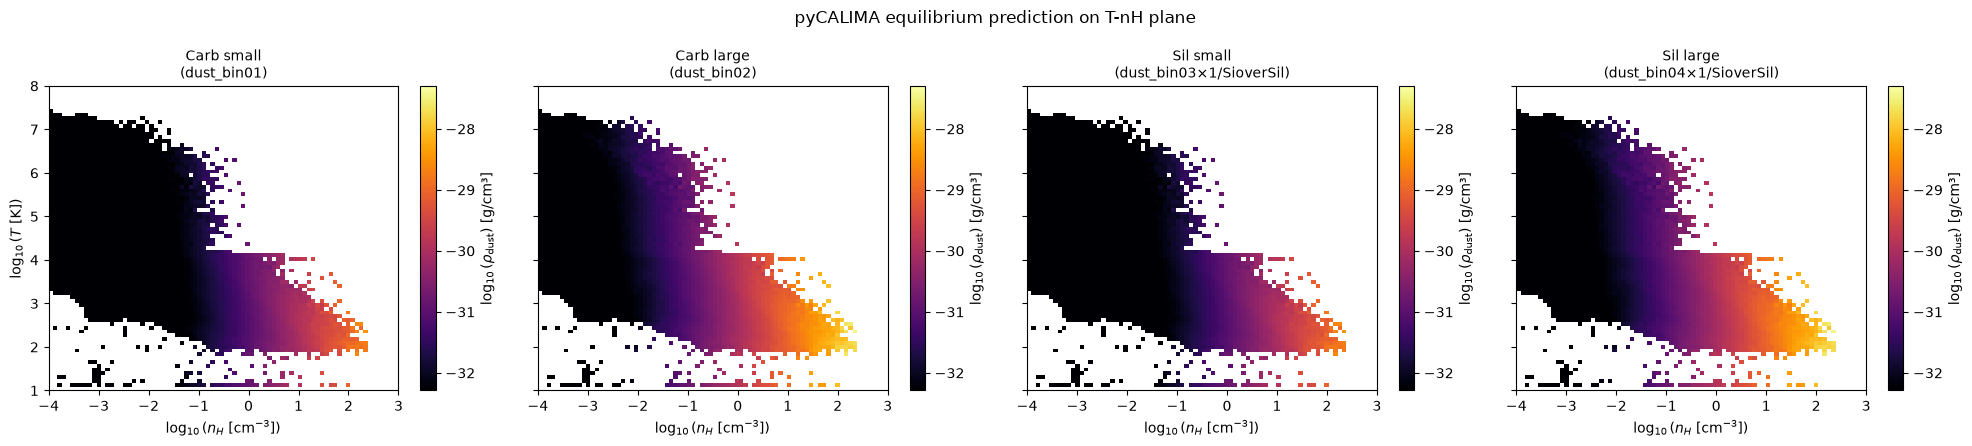

In [13]:
EQ_BINS = [rho_cs_eq, rho_cl_eq, rho_ss_eq, rho_sl_eq]

# Global colour limits based on simulation
ref_dust = np.concatenate([b[b > 0] for b in SIM_BINS])
vmin_common = np.log10(np.percentile(ref_dust, 5))
vmax_common = np.log10(np.percentile(ref_dust, 95))

fig_sim = phase_rho_dust(
    T_gas, nH, SIM_BINS, BIN_LABELS, vol,
    vmin=vmin_common, vmax=vmax_common,
    title='RAMSES simulation: dust mass density on T-nH plane'
)
plt.savefig('results/compare_sim_Tnplane.png', dpi=150, bbox_inches='tight')
plt.show()

fig_eq = phase_rho_dust(
    T_gas, nH, EQ_BINS, BIN_LABELS, vol,
    vmin=vmin_common, vmax=vmax_common,
    title='pyCALIMA equilibrium prediction on T-nH plane'
)
plt.savefig('results/compare_eq_Tnplane.png', dpi=150, bbox_inches='tight')
plt.show()

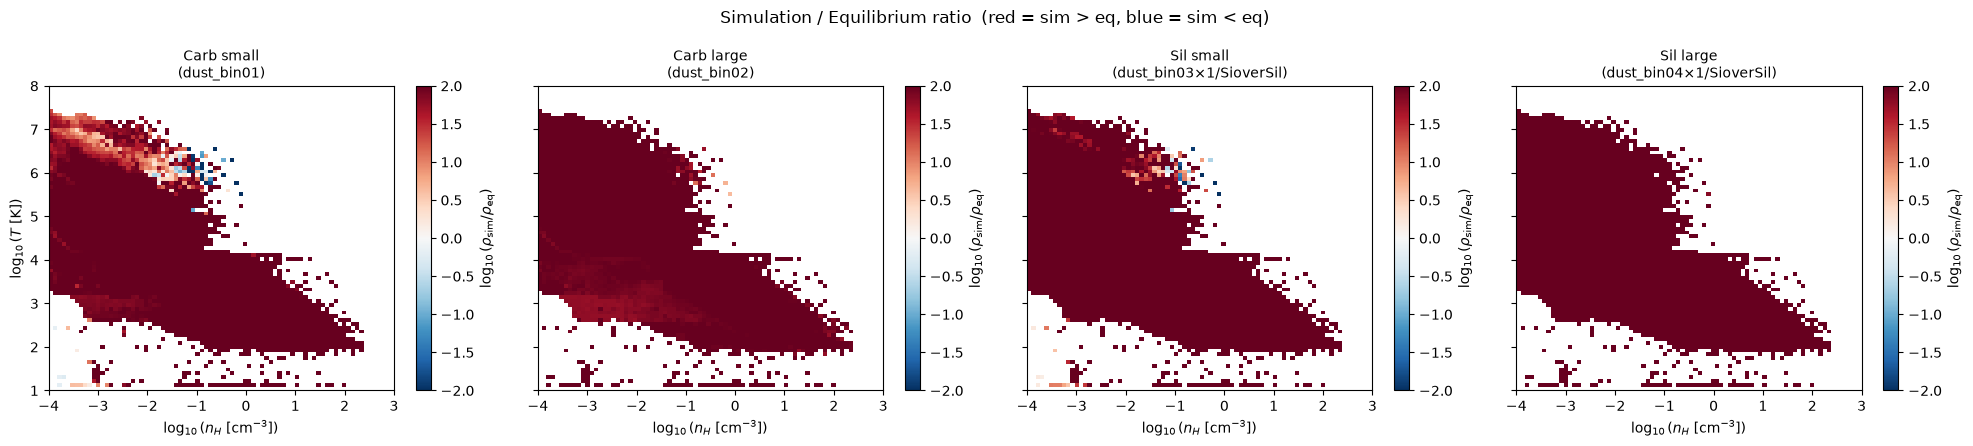

In [14]:
# ── Ratio map: log₁₀(simulation / equilibrium) ───────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5), sharey=True)
log_nH_c = np.log10(np.clip(nH,    1e-5, 1e4))
log_T_c  = np.log10(np.clip(T_gas, 1e0,  1e9))

for ax, rho_sim_bin, rho_eq_bin, label in zip(axes, SIM_BINS, EQ_BINS, BIN_LABELS):
    with np.errstate(invalid='ignore', divide='ignore'):
        log_ratio = np.log10((rho_sim_bin + 1e-40) / (rho_eq_bin + 1e-40))

    h_ratio, xe, ye = np.histogram2d(log_nH_c, log_T_c, bins=NBINS_2D,
                                      range=[NH_RANGE, T_RANGE],
                                      weights=log_ratio * vol)
    h_vol, _, _     = np.histogram2d(log_nH_c, log_T_c, bins=NBINS_2D,
                                      range=[NH_RANGE, T_RANGE],
                                      weights=vol)
    with np.errstate(invalid='ignore'):
        mean_ratio = np.where(h_vol > 0, h_ratio / h_vol, np.nan)

    im = ax.pcolormesh(xe, ye, mean_ratio.T, cmap='RdBu_r', vmin=-2, vmax=2)
    ax.set_xlabel(r'$\log_{10}(n_H\ [\mathrm{cm}^{-3}])$')
    ax.set_title(label, fontsize=10)
    plt.colorbar(im, ax=ax, label=r'$\log_{10}(\rho_\mathrm{sim}/\rho_\mathrm{eq})$')

axes[0].set_ylabel(r'$\log_{10}(T\ [\mathrm{K}])$')
fig.suptitle(
    'Simulation / Equilibrium ratio  (red = sim > eq, blue = sim < eq)',
    fontsize=12
)
plt.tight_layout()
plt.savefig('results/compare_ratio_Tnplane.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Comparison: global distributions

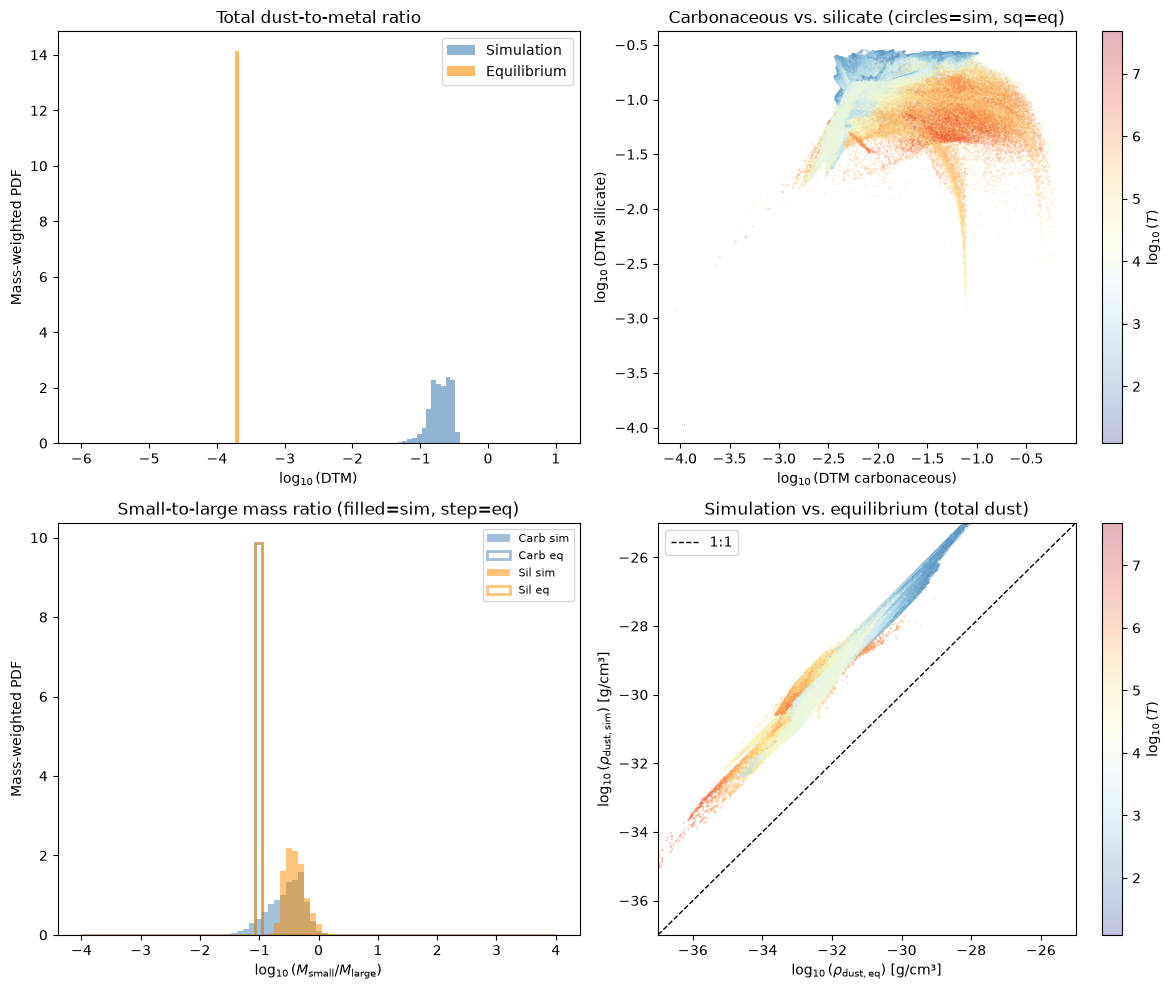

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# ── Panel 1: total DTM histogram ──────────────────────────────────────────────
ax = axes[0, 0]
good = (DTM_sim > 0) & (DTM_eq_total > 0) & (~out_of_bounds)
bins_dtm = np.linspace(-6, 1, 100)
ax.hist(np.log10(DTM_sim[good]), bins=bins_dtm, weights=cell_mass[good],
        density=True, alpha=0.6, color='steelblue', label='Simulation')
ax.hist(np.log10(DTM_eq_total[good]), bins=bins_dtm, weights=cell_mass[good],
        density=True, alpha=0.6, color='darkorange', label='Equilibrium')
ax.set_xlabel(r'$\log_{10}$(DTM)')
ax.set_ylabel('Mass-weighted PDF')
ax.set_title('Total dust-to-metal ratio')
ax.legend()

# ── Panel 2: carb vs sil DTM ──────────────────────────────────────────────────
ax = axes[0, 1]
DTM_carb_sim = np.where(rho_metal > 0, (rho_cs + rho_cl) / rho_metal, 0)
DTM_sil_sim  = np.where(rho_metal > 0, (rho_ss + rho_sl) / rho_metal, 0)
DTM_carb_eq  = np.where(rho_metal > 0, (rho_cs_eq + rho_cl_eq) / rho_metal, 0)
DTM_sil_eq   = np.where(rho_metal > 0, (rho_ss_eq + rho_sl_eq) / rho_metal, 0)

color_T = np.log10(np.clip(T_gas[good], 1e1, 1e8))
sc = ax.scatter(np.log10(DTM_carb_sim[good] + 1e-7),
                np.log10(DTM_sil_sim[good]  + 1e-7),
                c=color_T, cmap='RdYlBu_r', s=0.1, alpha=0.3, label='Sim')
ax.scatter(np.log10(DTM_carb_eq[good] + 1e-7),
           np.log10(DTM_sil_eq[good]  + 1e-7),
           c=color_T, cmap='RdYlBu_r', s=0.1, alpha=0.3, marker='s', label='Eq')
plt.colorbar(sc, ax=ax, label=r'$\log_{10}(T)$')
ax.set_xlabel(r'$\log_{10}$(DTM carbonaceous)')
ax.set_ylabel(r'$\log_{10}$(DTM silicate)')
ax.set_title('Carbonaceous vs. silicate (circles=sim, sq=eq)')

# ── Panel 3: small/large ratio per composition ────────────────────────────────
ax = axes[1, 0]
pos = good & (rho_cl > 0) & (rho_sl > 0) & (rho_cl_eq > 0) & (rho_sl_eq > 0)
ratio_carb_sim = np.log10((rho_cs[pos] + 1e-40) / (rho_cl[pos] + 1e-40))
ratio_sil_sim  = np.log10((rho_ss[pos] + 1e-40) / (rho_sl[pos] + 1e-40))
ratio_carb_eq  = np.log10((rho_cs_eq[pos] + 1e-40) / (rho_cl_eq[pos] + 1e-40))
ratio_sil_eq   = np.log10((rho_ss_eq[pos] + 1e-40) / (rho_sl_eq[pos] + 1e-40))

bins_r = np.linspace(-4, 4, 80)
ax.hist(ratio_carb_sim, bins=bins_r, weights=cell_mass[pos], density=True,
        alpha=0.5, color='steelblue', label='Carb sim')
ax.hist(ratio_carb_eq,  bins=bins_r, weights=cell_mass[pos], density=True,
        alpha=0.5, color='steelblue', histtype='step', lw=2, label='Carb eq')
ax.hist(ratio_sil_sim,  bins=bins_r, weights=cell_mass[pos], density=True,
        alpha=0.5, color='darkorange', label='Sil sim')
ax.hist(ratio_sil_eq,   bins=bins_r, weights=cell_mass[pos], density=True,
        alpha=0.5, color='darkorange', histtype='step', lw=2, label='Sil eq')
ax.set_xlabel(r'$\log_{10}(M_\mathrm{small}/M_\mathrm{large})$')
ax.set_ylabel('Mass-weighted PDF')
ax.set_title('Small-to-large mass ratio (filled=sim, step=eq)')
ax.legend(fontsize=8)

# ── Panel 4: 1-to-1 scatter (total dust) ─────────────────────────────────────
ax = axes[1, 1]
pos2 = good & (rho_dust > 0) & (rho_dust_eq > 0)
sc2 = ax.scatter(np.log10(rho_dust_eq[pos2]), np.log10(rho_dust[pos2]),
                 c=np.log10(T_gas[pos2]), cmap='RdYlBu_r',
                 s=0.3, alpha=0.3, rasterized=True)
lims = (-37, -25)
ax.plot(lims, lims, 'k--', lw=1, label='1:1')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel(r'$\log_{10}(\rho_\mathrm{dust,eq})$ [g/cm³]')
ax.set_ylabel(r'$\log_{10}(\rho_\mathrm{dust,sim})$ [g/cm³]')
ax.set_title('Simulation vs. equilibrium (total dust)')
plt.colorbar(sc2, ax=ax, label=r'$\log_{10}(T)$')
ax.legend()

plt.tight_layout()
plt.savefig('results/compare_global.png', dpi=150, bbox_inches='tight')
plt.show()

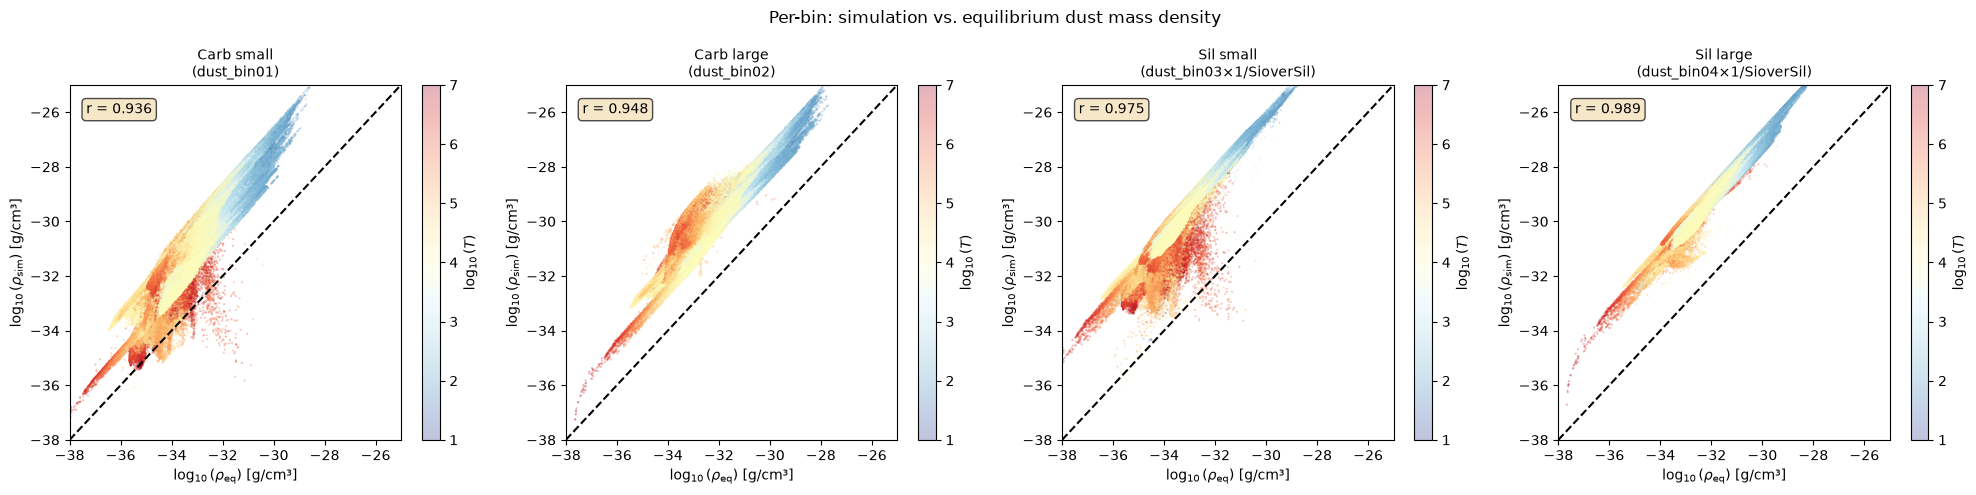

In [16]:
# ── Per-bin 1-to-1 scatter ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
lims = (-38, -25)

for ax, rho_sim_bin, rho_eq_bin, label in zip(axes, SIM_BINS, EQ_BINS, BIN_LABELS):
    pos_b = good & (rho_sim_bin > 0) & (rho_eq_bin > 0)
    sc = ax.scatter(
        np.log10(rho_eq_bin[pos_b]), np.log10(rho_sim_bin[pos_b]),
        c=np.log10(T_gas[pos_b]), cmap='RdYlBu_r', vmin=1, vmax=7,
        s=0.3, alpha=0.3, rasterized=True
    )
    ax.plot(lims, lims, 'k--', lw=1.5)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel(r'$\log_{10}(\rho_\mathrm{eq})$ [g/cm³]')
    ax.set_ylabel(r'$\log_{10}(\rho_\mathrm{sim})$ [g/cm³]')
    ax.set_title(label, fontsize=10)
    plt.colorbar(sc, ax=ax, label=r'$\log_{10}(T)$')
    # Print Pearson r in log space
    r = np.corrcoef(np.log10(rho_eq_bin[pos_b]), np.log10(rho_sim_bin[pos_b]))[0, 1]
    ax.text(0.05, 0.92, f'r = {r:.3f}', transform=ax.transAxes, fontsize=10,
            color='black', bbox=dict(boxstyle='round', fc='wheat', alpha=0.7))

fig.suptitle('Per-bin: simulation vs. equilibrium dust mass density', fontsize=12)
plt.tight_layout()
plt.savefig('results/compare_per_bin_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Summary and interpretation

### What the comparison shows

- **Agreement regime**: In the warm neutral/molecular medium (T ~ 100–8000 K, nH ~ 1–100 cm⁻³) the simulation should approach equilibrium values if the run time is long enough relative to the accretion timescale τ_acc ~ 1/(nH × k_acc).

- **Simulation below equilibrium** (blue in ratio maps): typically in dense, cold gas (T < 300 K, nH > 100 cm⁻³) where dust accretion is fast but the simulation DTMini = 10⁻³ starting point may not have had time to reach equilibrium, *or* the equilibrium predicts very high DTM that has not been reached.

- **Simulation above equilibrium** (red in ratio maps): typically in hot, diffuse gas (T > 10⁵ K, nH < 0.1 cm⁻³) where the equilibrium predicits near-zero dust (thermal sputtering destroys it), but the simulation retains some dust that was advected from denser regions before being sputtered.

### Caveats
1. **G0 = 1 (assumed)**: The UV field varies across the galaxy. Cells near star-forming regions could have G0 ≫ 1, which would reduce the equilibrium DTM (more photoelectric heating → less accretion).
2. **Fixed σ**: The turbulence parameter is set to the mass-weighted mean; individual cells with much higher/lower σ will have different coagulation/shattering equilibria.
3. **Fixed 0.1 Z☉ budget**: Per-cell element abundances vary; the equilibrium is scaled by the cell's *gas-phase* metallicity, which underestimates the total budget by the amount locked in dust.
4. **No PAH bins in RAMSES**: The 4 dust bins in RAMSES have no PAH equivalent; pyCALIMA's PAH physics is not exercised here.

### Next steps
- Extend the grid to include G0 as a third axis (estimated from local SFR density)
- Use per-cell total element budget (gas + dust) for a more accurate equilibrium constraint
- Add a time-evolution comparison: run pyCALIMA RK4 from the simulation's initial DTM and check if it converges to the simulation values